<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/fertilizer-scheduling-model/FerilizerSchedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

Cleaning Data, Preprocessing data and feature engineering for Fertilizer dataset.

In [52]:
#fertilizer dataset
fert = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Fertilizer_History.csv', header=None)
fert.columns = ["Division", "Field", "Area", "Type", "Date", "Amount", "Block", "Extra"]
fert = fert.drop(columns=["Extra"]).dropna(how='all')

fert['Division'] = fert['Division'].ffill()
fert = fert[fert['Field'].notna() & (fert['Field'] != 0) & (fert['Field'] != '-') & (fert['Field'] != 'Field')]
fert = fert[fert['Division'] != 'Division']

fert['Area']   = pd.to_numeric(fert['Area'],   errors='coerce')
fert['Amount'] = pd.to_numeric(fert['Amount'], errors='coerce')
fert = fert.dropna(subset=['Area','Amount'])
fert['Date'] = fert['Date'].astype(str).str.replace('Sept', 'Sep', regex=False)
fert['Date'] = pd.to_datetime(fert['Date'], format='%d-%b-%y', errors='coerce')
fert = fert.dropna(subset=['Date'])
fert = fert[fert['Date'].dt.year > 2000]

fert['Month'] = fert['Date'].dt.strftime('%B')

#Feature Engineer
fert['Fertilizer_per_area'] = fert['Amount'] / fert['Area']
fert = fert.sort_values(by=['Division','Field','Date']).reset_index(drop=True)

print("Fert shape:", fert.shape)
print(fert[['Division','Field','Date','Amount']].head())

Fert shape: (65, 9)
  Division Field       Date  Amount
0      AGO    3A 2023-02-12    30.0
1      AGO    3B 2023-08-18    24.0
2      AGO    4A 2024-08-31    11.0
3      AGO    9G 2025-02-02     6.0
4      AGO    9H 2024-03-21    16.0


Cleaning Data, Preprocessing data and feature engineering for the yeild dataset.

In [53]:
#yeild dataset
yield_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Block_Metadata.csv', header=None)
yield_df = yield_df.dropna(how='all').reset_index(drop=True)
yield_df = yield_df.iloc[4:].reset_index(drop=True)  # skip header rows

yield_df.columns = [
    'Division', 'Asst_Manager', 'Field', 'Area', 'Type',
    'Planting_Year', 'Last_Pruned', 'Age_Months'
] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]

#Clean numeric columns
numeric_cols = ['Area','Age_Months'] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]
for col in numeric_cols:
    yield_df[col] = pd.to_numeric(yield_df[col].astype(str).str.replace(',',''), errors='coerce')
yield_df[numeric_cols] = yield_df[numeric_cols].fillna(yield_df[numeric_cols].median())
yield_df['Division']    = yield_df['Division'].ffill()
yield_df['Field']       = yield_df['Field'].ffill()
yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)

#Feature engineering
yield_df['Yield_per_ha']         = yield_df['Year_1'] / yield_df['Area']
last_5_cols                       = [col for col in yield_df.columns if 'Year_' in col][:5]
yield_df['Avg_Yield_Last5Y']     = yield_df[last_5_cols].mean(axis=1)
yield_df['Yield_Trend']          = yield_df['Year_1'] - yield_df['Avg_Yield_Last5Y']  # positive = improving
yield_df['Months_Since_Pruning'] = yield_df['Age_Months'] - ((pd.to_datetime('2025-09-01') - yield_df['Last_Pruned']).dt.days/30)
yield_df['Months_Since_Pruning'] = yield_df['Months_Since_Pruning'].fillna(yield_df['Months_Since_Pruning'].median())

yield_features = yield_df[['Division','Field','Area','Age_Months','Yield_per_ha','Avg_Yield_Last5Y','Yield_Trend','Months_Since_Pruning']]

/tmp/ipykernel_202/3712849259.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)


Cleaning Data, Preprocessing data and feature engineering for climate dataset.

In [54]:
#Climate dataset
climate = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Climate_Data.csv', header=None)
climate = climate.dropna(how='all').reset_index(drop=True)

months = ['January','February','March','April','May','June','July','August','September','October','November','December']
climate = climate[climate[0].str.strip().isin(months)].reset_index(drop=True)

n_cols = climate.shape[1]
columns = ['Month']
num_years = (n_cols - 1)//2
for i in range(num_years):
    columns += [f'Wetdays_Year_{i+1}', f'Rainfall_Year_{i+1}']
if len(columns) != n_cols:
    columns += [f'Extra_{i}' for i in range(len(columns), n_cols)]
climate.columns = columns

# Clean numeric
for col in climate.columns[1:]:
    climate[col] = pd.to_numeric(climate[col].astype(str).str.replace(',','').str.replace('-','').str.strip(), errors='coerce')
non_empty_cols = [c for c in climate.columns if climate[c].notna().sum() > 0 or c=='Month']
climate = climate[non_empty_cols]

rainfall_cols = [c for c in climate.columns if 'Rainfall' in c]
wetdays_cols = [c for c in climate.columns if 'Wetdays' in c]

climate['Rainfall_Mean'] = climate[rainfall_cols].mean(axis=1)
climate['Rainfall_Max'] = climate[rainfall_cols].max(axis=1)
climate['Rainfall_Min'] = climate[rainfall_cols].min(axis=1)
climate['Wetdays_Mean'] = climate[wetdays_cols].mean(axis=1)

def compute_trend(row):
    y = row[rainfall_cols].values.astype(float)
    valid_idx = ~np.isnan(y)
    if valid_idx.sum()<2:
        return 0
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x[valid_idx], y[valid_idx])
    return slope

climate['Rainfall_Trend'] = climate.apply(compute_trend, axis=1)

Clean, pre-process and fature engineer plucking round dataset

In [55]:
# Plucking rounds dataset
today = pd.Timestamp.today().normalize()

df_pluck = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Last_10_Year_Data_-_PLUCKING_ROUNDS_-AS_AT_JUNE-25.csv', header=None)
df_pluck.columns = ['Field','Type','Extent','Rounds_2526','Rounds_2425','Rounds_2324']

division_map = {
    'AGROYA DIVISION': 'AGO', 'LOWER DANDUKELLEWA DIVISION': 'LDK',
    'LOWER VELLAI OYA DIVISION': 'LVO', 'UPPER DANDUKELLEWA DIVISION': 'UDK',
    'UPPER VELLAI OYA DIVISION': 'UVO'
}
df_pluck['Division'] = df_pluck['Field'].map(division_map).ffill()

pluck = df_pluck[~df_pluck['Field'].astype(str).str.contains(
    'Division|Estate|PLUCKING|Field|Type', na=True)].copy()
pluck = pluck[pluck['Field'].notna()].copy()

#Convert to numeric
for c in ['Rounds_2526','Rounds_2425','Rounds_2324','Extent']:
    pluck[c] = pd.to_numeric(pluck[c].astype(str).str.strip().replace('-',''), errors='coerce')
pluck['Field'] = pluck['Field'].astype(str).str.strip()

#Feature engineering
pluck['Rounds_Trend'] = pluck['Rounds_2425'] - pluck['Rounds_2324']
pluck['Rounds_Pct_Change'] = ((pluck['Rounds_2425'] - pluck['Rounds_2324']) / pluck['Rounds_2324'] * 100).round(1)
pluck['Rounds_Mean'] = pluck[['Rounds_2324','Rounds_2425']].mean(axis=1)

print("Plucking rounds shape:", pluck.shape)
print(pluck[['Division','Field','Rounds_2324','Rounds_2425','Rounds_Trend','Rounds_Pct_Change']].head(10))

Plucking rounds shape: (70, 10)
   Division                        Field  Rounds_2324  Rounds_2425  \
4       AGO              AGROYA DIVISION          NaN          NaN   
5       AGO                           3A         29.0         29.0   
6       AGO                           3B         22.0         31.0   
7       AGO                           4A         30.0         21.0   
8       AGO                           9G         30.0         24.0   
9       AGO                           9H         27.0         30.0   
10      AGO                           9I         34.0         28.0   
12      LDK  LOWER DANDUKELLEWA DIVISION          NaN          NaN   
13      LDK                           44         19.0         29.0   
14      LDK                           45         32.0         30.0   

    Rounds_Trend  Rounds_Pct_Change  
4            NaN                NaN  
5            0.0                0.0  
6            9.0               40.9  
7           -9.0              -30.0  
8      

Merging the datasets


In [56]:
merged_df = pd.merge(fert, yield_features, on=['Division','Field'], how='left')
merged_df = pd.merge(merged_df, climate[['Month','Rainfall_Mean','Wetdays_Mean']], on='Month', how='left')
merged_df = pd.merge(merged_df, pluck[['Division','Field','Rounds_2324','Rounds_2425','Rounds_Trend','Rounds_Pct_Change','Rounds_Mean','Extent']], on=['Division','Field'], how='left')

#Using median to impute missing values
num_cols = merged_df.select_dtypes(include=np.number).columns
merged_df[num_cols] = merged_df[num_cols].fillna(merged_df[num_cols].median())

print("Final Merged Dataset:")
print(merged_df.head())
print("\nShape:", merged_df.shape)
print("\nColumns:", merged_df.columns.tolist())

Final Merged Dataset:
  Division Field  Area_x Type       Date  Amount  Block     Month  \
0      AGO    3A     5.0   VP 2023-02-12    30.0    NaN  February   
1      AGO    3B     4.5   VP 2023-08-18    24.0    NaN    August   
2      AGO    4A     4.0   VP 2024-08-31    11.0    NaN    August   
3      AGO    9G     4.0   VP 2025-02-02     6.0    NaN  February   
4      AGO    9H     4.0   VP 2024-03-21    16.0    NaN     March   

   Fertilizer_per_area  Area_y  ...  Yield_Trend  Months_Since_Pruning  \
0             6.000000     5.0  ...       -322.4             -0.066667   
1             5.333333     4.5  ...       -298.8              0.166667   
2             2.750000     4.0  ...       -328.8             -0.200000   
3             1.500000     4.0  ...       -553.6             -0.033333   
4             4.000000     4.0  ...       -151.4              0.366667   

   Rainfall_Mean  Wetdays_Mean  Rounds_2324  Rounds_2425  Rounds_Trend  \
0      96.000000      6.142857         29.0 

Performing Exploratory data analysis on the merged dataset

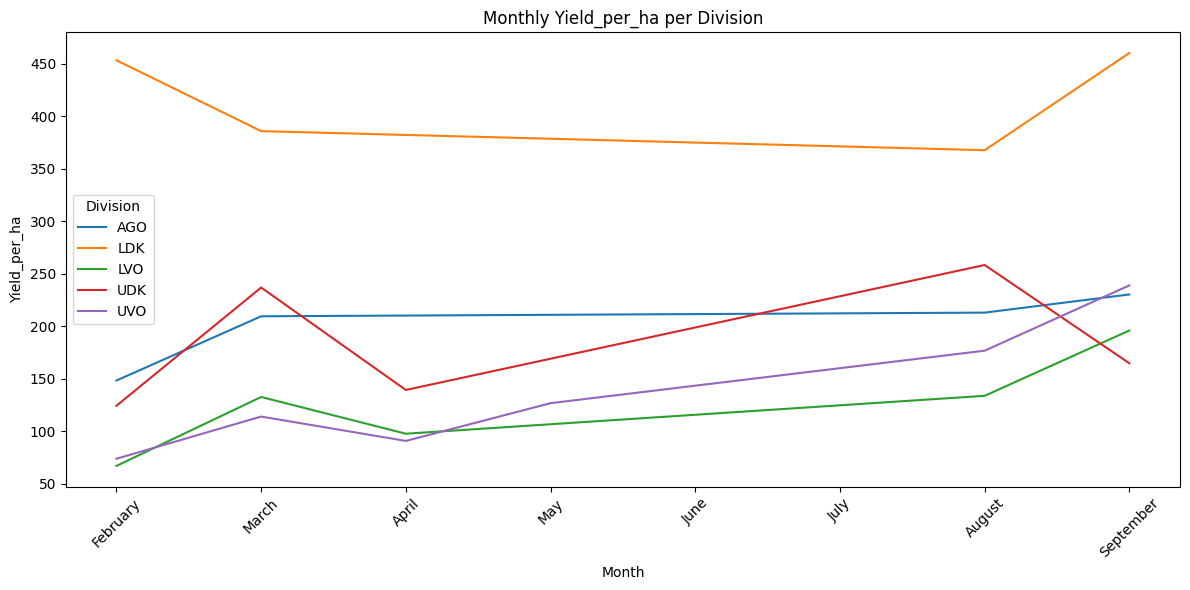

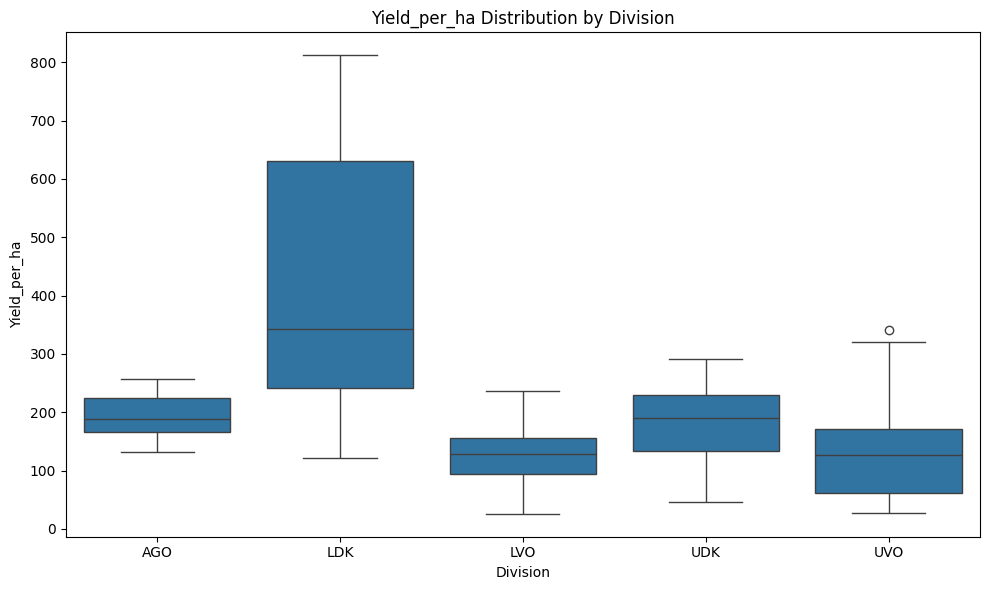

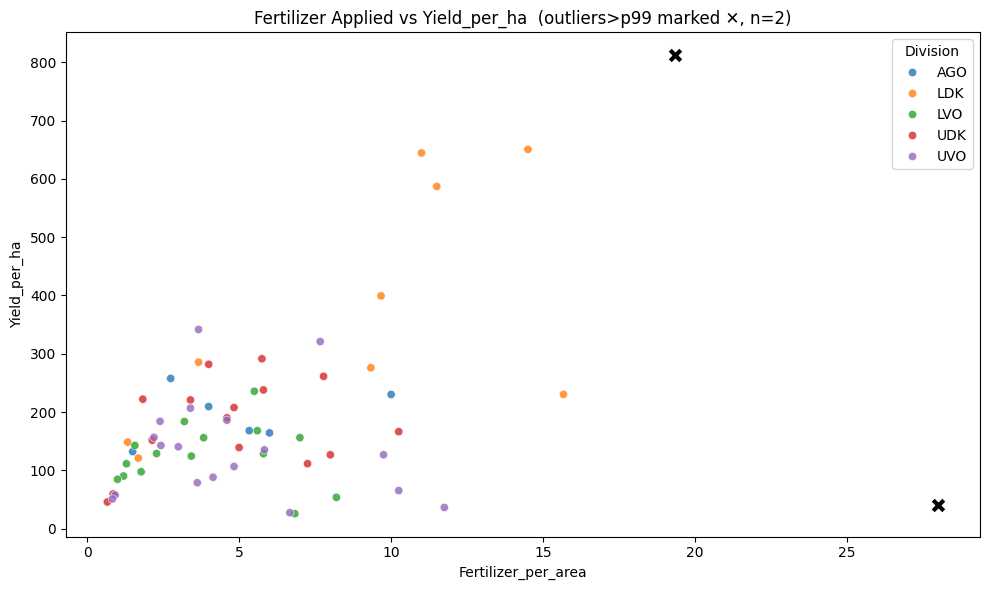


Top correlated numeric features with Yield_per_ha:
 Avg_Yield_Last5Y       0.678948
Area_x                 0.609186
Rounds_2425            0.531675
Rounds_Mean            0.439239
Rounds_Trend           0.419709
Fertilizer_per_area    0.408427
Days_Until_Due         0.404136
Division_enc           0.373950
Age_Months             0.254738
Month_enc              0.227363
Name: Yield_per_ha, dtype: float64


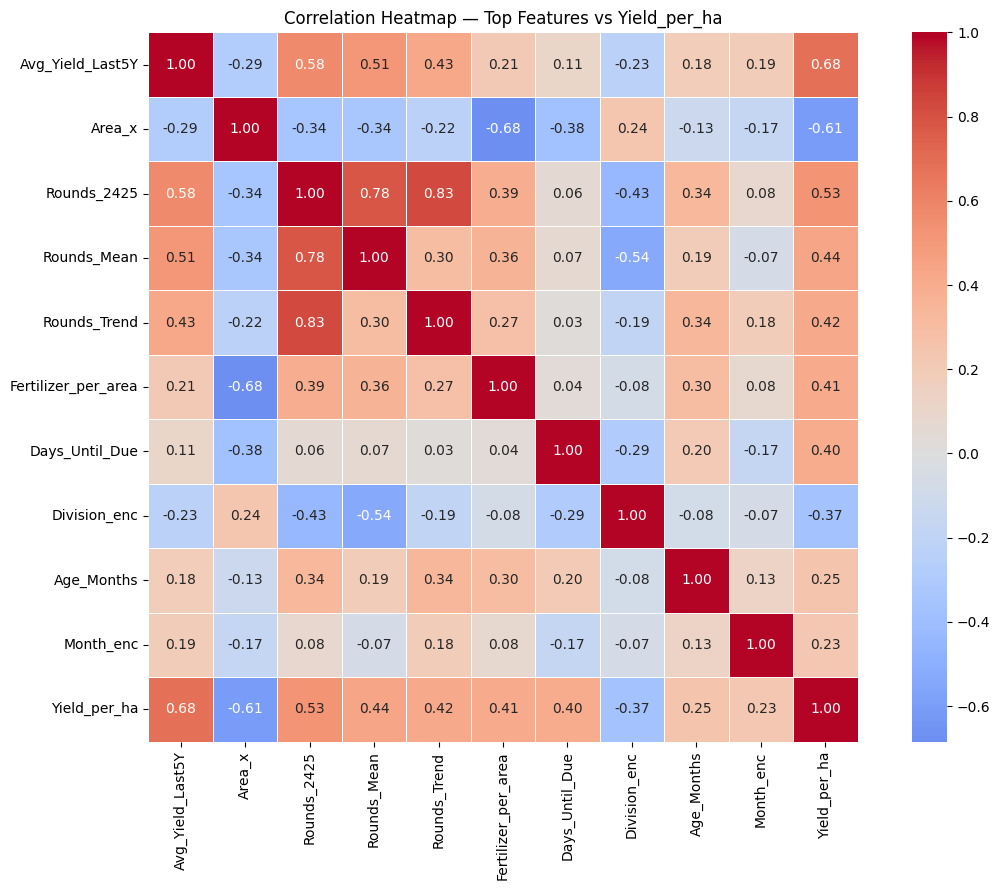

In [75]:
merged_df = merged_df.drop(columns=['Area_y','Extent','Rounds_3Y_Mean','Yield_x_Round','AmountPerHa','Rounds_Pct_Change'], errors='ignore')
df = merged_df.copy()
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

# Lineplot
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Month', y='Yield_per_ha', hue='Division', errorbar=None)
plt.title("Monthly Yield_per_ha per Division")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Division', y='Yield_per_ha')
plt.title("Yield_per_ha Distribution by Division")
plt.tight_layout()
plt.show()

# Scatterplot to see outliers
p99_fert  = df['Fertilizer_per_area'].quantile(0.99)
p99_yield = df['Yield_per_ha'].quantile(0.99)
df_main    = df[(df['Fertilizer_per_area'] <= p99_fert) & (df['Yield_per_ha'] <= p99_yield)]
df_outlier = df[(df['Fertilizer_per_area'] > p99_fert)  | (df['Yield_per_ha'] > p99_yield)]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df_main,x='Fertilizer_per_area', y='Yield_per_ha', hue='Division', alpha=0.8)
sns.scatterplot(data=df_outlier, x='Fertilizer_per_area', y='Yield_per_ha', marker='X', s=120, color='black', label='Outlier', legend=False)
plt.title(f"Fertilizer Applied vs Yield_per_ha  (outliers>p99 marked ✕, n={len(df_outlier)})")
plt.tight_layout()
plt.show()

# Correlation heatmap with top features
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()
top_corr = corr_matrix['Yield_per_ha'].abs().sort_values(ascending=False)[1:11]
print("\nTop correlated numeric features with Yield_per_ha:\n", top_corr)

top_features = top_corr.index.tolist() + ['Yield_per_ha']
plt.figure(figsize=(12,9))
sns.heatmap(
    df[top_features].corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0,
    square=True, linewidths=0.5
)
plt.title("Correlation Heatmap — Top Features vs Yield_per_ha")
plt.tight_layout()
plt.show()

In [58]:
# Random forest regressor to predict fertilizer amount
merged_df['AmountPerHa']   = merged_df['Amount'] / merged_df['Area_x']
merged_df['Division_enc']  = LabelEncoder().fit_transform(merged_df['Division'])
merged_df['Month_enc']     = pd.to_datetime(merged_df['Month'], format='%B').dt.month
merged_df['Season']        = merged_df['Month_enc'].apply(lambda m: 1 if m in [5,6,7,8,9,10] else 0)
merged_df['Yield_x_Round'] = merged_df['Yield_per_ha'] * merged_df['Rounds_Mean']
merged_df['Age_sq']        = merged_df['Age_Months'] ** 2
merged_df['Rounds_3Y_Mean']= merged_df[['Rounds_2324','Rounds_2425']].mean(axis=1)

feature_cols = [
    'Avg_Yield_Last5Y', 'Yield_Trend', 'Yield_per_ha', 'Months_Since_Pruning','Rainfall_Mean', 'Wetdays_Mean',
    'Division_enc', 'Month_enc', 'Season', 'Age_Months', 'Age_sq', 'Rounds_2324', 'Rounds_2425', 'Rounds_Trend',
    'Rounds_Pct_Change','Rounds_Mean', 'Rounds_3Y_Mean', 'Yield_x_Round'
]

X = merged_df[feature_cols]
y = merged_df['AmountPerHa']

# Shuffle before split
X_s, y_s = shuffle(X, y, random_state=42)
split_idx   = int(len(X_s) * 0.8)
X_train_raw = X_s.iloc[:split_idx]
X_test_raw  = X_s.iloc[split_idx:]

# Using median for training dataset
train_median = X_train_raw.median()
X_train = X_train_raw.fillna(train_median)
X_test  = X_test_raw.fillna(train_median)
y_train = y_s.iloc[:split_idx]
y_test  = y_s.iloc[split_idx:]

model = RandomForestRegressor(n_estimators=500,
                              max_depth=6,
                              min_samples_leaf=2,
                              max_features='sqrt',
                              random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

train_r2 = r2_score(y_train, model.predict(X_train))
test_r2  = r2_score(y_test,  y_pred)
print("Model Performance (Fertilizer Amount)")
print("MAE:", round(mean_absolute_error(y_test, y_pred), 2), "kg/ha")
print("R²:", round(test_r2,  3))

#Feature importance
X_full = X.fillna(train_median)
model.fit(X_full, y)
feature_importance = pd.Series(
    model.feature_importances_, index=feature_cols
).sort_values(ascending=False)
print("\nTop 10 Important Features:")
print(feature_importance.head(10).round(3))

bins   = [0, 4, 7, 999]
labels = ['Low', 'Medium', 'High']
y_test_cls = pd.cut(y_test, bins=bins, labels=labels)
y_pred_cls = pd.cut(y_pred, bins=bins, labels=labels)
print(classification_report(y_test_cls, y_pred_cls, labels=labels, zero_division=0))

Model Performance (Fertilizer Amount)
MAE: 1.84 kg/ha
R²: 0.661

Top 10 Important Features:
Yield_x_Round        0.126
Yield_per_ha         0.097
Rounds_2425          0.097
Age_sq               0.088
Age_Months           0.085
Rounds_Mean          0.084
Rounds_3Y_Mean       0.083
Avg_Yield_Last5Y     0.079
Rounds_Pct_Change    0.058
Yield_Trend          0.054
dtype: float64
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         4
      Medium       0.80      1.00      0.89         4
        High       1.00      0.80      0.89         5

    accuracy                           0.92        13
   macro avg       0.93      0.93      0.93        13
weighted avg       0.94      0.92      0.92        13



In [67]:
# Random forest regressor to predict recommended fertilizer interval
merged_df['Days_Since_Application'] = (today - merged_df['Date']).dt.days
merged_df['AmountPerHa']  = merged_df['Amount'] / merged_df['Area_x']
merged_df['Division_enc'] = LabelEncoder().fit_transform(merged_df['Division'])

feature_cols = [
    'Rounds_2324', 'Rounds_2425', 'Rounds_Trend', 'Rounds_Pct_Change',
    'Rounds_Mean', 'AmountPerHa', 'Extent', 'Division_enc'
]

X = merged_df[feature_cols]
y = merged_df['Days_Since_Application']

X_s, y_s = shuffle(X, y, random_state=42)
split_idx   = int(len(X_s) * 0.8)
X_train_raw = X_s.iloc[:split_idx]
X_test_raw  = X_s.iloc[split_idx:]

train_median = X_train_raw.median()
X_train = X_train_raw.fillna(train_median)
X_test  = X_test_raw.fillna(train_median)
y_train = y_s.iloc[:split_idx]
y_test  = y_s.iloc[split_idx:]

model_days = RandomForestRegressor(n_estimators=300, max_depth=5, min_samples_leaf=3, random_state=42)
model_days.fit(X_train, y_train)
y_pred = model_days.predict(X_test)

train_r2 = r2_score(y_train, model_days.predict(X_train))
test_r2  = r2_score(y_test,  y_pred)
print("Model Performance — Predicted Interval Days")
print(f"MAE : {mean_absolute_error(y_test, y_pred):.0f} days")
print(f"R^2: {round(test_r2,  3)}")

#Feature importance
X_full = X.fillna(train_median)
model_days.fit(X_full, y)
fi = pd.Series(model_days.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nTop Features:")
print(fi.round(3))

bins_days   = [0, 600, 1095, 9999]
labels_days = ['Recent (<600d)', 'Moderate (600d-3yr)', 'Old (>3yr)']
y_test_cls = pd.cut(y_test, bins=bins_days, labels=labels_days)
y_pred_cls = pd.cut(y_pred, bins=bins_days, labels=labels_days)
print(classification_report(y_test_cls, y_pred_cls, zero_division=0))

Model Performance — Predicted Interval Days
MAE : 126 days
R^2: 0.856

Top Features:
AmountPerHa          0.816
Rounds_2324          0.073
Rounds_Pct_Change    0.049
Rounds_Trend         0.032
Extent               0.010
Rounds_2425          0.009
Rounds_Mean          0.007
Division_enc         0.005
dtype: float64
                     precision    recall  f1-score   support

Moderate (600d-3yr)       0.67      1.00      0.80         2
         Old (>3yr)       1.00      0.88      0.93         8
     Recent (<600d)       1.00      1.00      1.00         3

           accuracy                           0.92        13
          macro avg       0.89      0.96      0.91        13
       weighted avg       0.95      0.92      0.93        13



Intergrating both the models to predict fertilizer amount and interval days

In [68]:
#Fertilizer Schdule
merged_df['Predicted_Interval_Days'] = model_days.predict(X_full).astype(int)
merged_df['Next_Application_Date'] = merged_df['Date'] + pd.to_timedelta(merged_df['Predicted_Interval_Days'], unit='D')
merged_df['Days_Until_Due'] = (merged_df['Next_Application_Date'] - today).dt.days
merged_df['Predicted_Amount_kg'] = (merged_df['AmountPerHa'] * merged_df['Area_x']).round(1)
merged_df['Status'] = merged_df['Days_Until_Due'].apply( lambda d: 'OVERDUE' if d < 0 else ('DUE SOON' if d <= 90 else 'UPCOMING'))

schedule = merged_df[[
    'Division', 'Field',
    'Date',
    'Predicted_Interval_Days',
    'Next_Application_Date',
    'Days_Until_Due',
    'Predicted_Amount_kg',
    'Status'
]].rename(columns={'Date': 'Last_Application'}).sort_values('Days_Until_Due').reset_index(drop=True)

print("\nFertilizer Schedule (Predicted Amount & Days)")
print("=" * 70)
print(schedule.to_string())
print(f"\nOVERDUE : {(schedule['Status']=='OVERDUE').sum()} fields")
print(f"DUE SOON : {(schedule['Status']=='DUE SOON').sum()} fields")
print(f"UPCOMING : {(schedule['Status']=='UPCOMING').sum()} fields")


Fertilizer Schedule (Predicted Amount & Days)
   Division Field Last_Application  Predicted_Interval_Days Next_Application_Date  Days_Until_Due  Predicted_Amount_kg    Status
0       LDK    51       2021-08-31                     1375            2025-06-06            -280                 47.0   OVERDUE
1       UVO   19B       2023-03-15                      845            2025-07-07            -249                 29.0   OVERDUE
2       UVO    17       2021-08-31                     1444            2025-08-14            -211                 47.0   OVERDUE
3       UDK    29       2022-02-26                     1349            2025-11-06            -127                 41.0   OVERDUE
4       LVO     8       2024-08-29                      448            2025-11-20            -113                 11.0   OVERDUE
5       UDK   27A       2022-04-08                     1328            2025-11-26            -107                 40.0   OVERDUE
6       LVO     7       2023-08-18                